In [ ]:
from IPython.display import display, HTML

display(HTML("""
<style>
.jp-RenderedHTMLCommon {
    max-width: 60vw;
    line-height: 1.5;
}
</style>
"""))

# Tutorial to Least Squares and Recursive Least Squares applied to tracking runner's performance

## Introduction to Least Squares

### Least Squares Background and Formulation

Least Squares (LS) is a powerful and widely used optimization technique commonly used to perform regression and/or parameter estimation. It achieves this by minimizing the sum of the squared differences between the observed data and predicted values by our model called residuals. The core idea is that smaller squared errors should mean a better fit of our model to the data.

Mathematically, for a linear system $\mathbf{A}\mathbf{x} = \mathbf{b}$, where we want to find the unknown parameter vector $\mathbf{x}$, the Least Squares solution $\hat{\mathbf{x}}$ is defined as the $\mathbf{x}$ that minimizes the following objective function:

$$ \hat{\mathbf{x}} = \underset{\mathbf{x}}{\operatorname{argmin}} \|\mathbf{A}\mathbf{x} - \mathbf{b}\|_2^2 $$

This optimization problem has a closed-form solution, which is derived by taking the derivative of the objective function with respect to $\mathbf{x}$ and setting it to zero.

Solving for $\hat{\mathbf{x}}$ gives us the Least Squares estimate:

$$ \hat{\mathbf{x}} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{b} $$

This solution provides the Moore-Penrose pseudo-inverse of $\mathbf{A}$, effectively giving us the $\hat{\mathbf{x}}$ that best satisfies an overdetermined (More measurements than parameters) system of equations.

## Runner Performance Modeling

Imagine a scenario where a runner trains daily for a 100m run. During training, he uses a sophisticated timer to keep a very accurate true time. He wants to know his pace over the 100m sprint during competition. However, on competition day, he will not have this sophisticated timer, so 3 coaches volunteered to record his times for that day. 1 coach will record times between distances (0 to 50) meters another between distances (50 to 100) meters, and the last at 100 meters.

We want to estimate his pace on competition day, knowing that runners typically accelerate in the first half and maintain speed in the second half.

Each of our coaches will measure the observed time. This defines our model:

$$t_{observed,j} = d_{1,j} \cdot \theta_1 + d_{2,j} \cdot \theta_2 + \epsilon_j$$

Where:
*   $\theta_1$: The model **parameter** representing the runner's pace (seconds per meter) in segment 1 (0-50m).
*   $\theta_2$: The model **parameter** representing the runner's pace (seconds per meter) in segment 2 (50-100m).
*   $d_{1,j} = \min(d_j, 50)$: The **known feature** being distance the runner traveled in segment 1 when passing coach $j$.
*   $d_{2,j} = \max(0, d_j - 50)$: The **known feature** being distance the runner traveled in segment 2 when passing coach $j$.
*   $\epsilon_j$: Coach $j$'s **measurement error** from timing imprecision and other unmodeled factors.

By estimating $\theta_1$ and $\theta_2$ from the three coaches' noisy time measurements, we can reconstruct the runner's true pace profile on competition day.
Because this equation is linear with respect to the model parameters, this problem can be formulated as a linear system suitable for Least Squares estimation.

### Potential LS reformulations (Beyond this tutorial's scope)

This tutorial focuses on recursive least squares (RLS). In practice, model formulation is a key requirement for good estimation (The other, being good data collection and processing). This section briefly speaks to some ways a problem can be creatively reformulated to find LS solutions, serving as a roadmap to those with different problems:

*   **Modeling with nonlinear parameters:**
  \
  Our piecewise linear model already provides a simple approximation of the runner's acceleration through reparameterization of speed (m/s) instead of pace (s/m). If we designed our model with speed, our equation would be nonlinear.
  \
  $$t_{observed,j} = d_{1,j} / v_1 + d_{2,j} / v_2 + \epsilon_j$$
  \
  A reparameterization of $\theta = 1/v$ results in the same equation, but not without drawbacks. The error associated to the linear $\theta$ parameter would scale nonlinearly after transforming it back to $v$.
  \
  \
  A more accurate nonlinear model would be the **exponential pace model**:
  $$
  \theta(d) = \theta_{ss} + (\theta_0 - \theta_{ss})e^{-\theta_r d}
  $$
  where the runner smoothly transitions from initial pace $\theta_0$ to steady-state pace $\theta_{ss}$ with rate $\lambda$. The cumulative time at distance $d_j$ is:
  $$
  t(d_j) = \theta_{ss} \cdot d_j + \frac{\theta_0 - \theta_{ss}}{\theta_r}(1 - e^{-\theta_r d_j})
  $$
  This model is **nonlinear** in the parameters due to $\lambda$ appearing in both the exponent and denominator, requiring iterative nonlinear estimation methods.
  \
  \
  Alternatively, we can apply least squares to a **linearized differential equation** formulation. The exponential model satisfies:
  $$
  \frac{d\theta}{dd} = -\theta_r(\theta - \theta_{ss})
  $$
  \
  This reparameterization onto the pace rate provides a physics-based linear approach, though it introduces additional noise through differentiation.


*   **Modeling with nonlinear features:**
  \
  Our piecewise linear model provides a simple approximation of the runner's acceleration. However, a smoother and more realistic model could use **polynomial features** to capture continuous pace changes:
  $$
  t(d_j) = \theta_0 \cdot d_j + \theta_1 \cdot \frac{d_j^2}{2} + \theta_2 \cdot \frac{d_j^3}{3} + \epsilon_j
  $$
  where the pace function $\theta(d) = \theta_0 + \theta_1 d + \theta_2 d^2$ varies smoothly with distance. The features $d_j$, $d_j^2$, and $d_j^3$ are **nonlinear transformations** of the coach positions, but the model remains **linear in the parameters** $(\theta_0, \theta_1, \theta_2)$ and can be solved using standard least squares. This approach captures smooth acceleration and deceleration without requiring nonlinear optimization, providing a middle ground between the simplicity of piecewise linear models and the complexity of fully nonlinear models.

*   **Estimating coach-specific timing bias**
  \
  Suppose the primary source of noise in the observed times comes from how each coach captures the split time at their position. We model this by introducing a coach-specific bias term:
  \
  $$
  t_{obs,j} = d_j^{(1)} \cdot \theta_1 + d_j^{(2)} \cdot \theta_2 + b_j + \epsilon_j
  $$
  \
  where $b_j$ captures the consistent timing bias associated with coach $j$ (e.g., one coach consistently starts their stopwatch early, another late). However, introducing a separate bias parameter for each coach often leads to an underdetermined system. With 4 coaches, we would have 5 parameters $$\theta_1, \theta_2, b_1, b_2, b_3$$ but only 3 measurements from a single run. This requires richer data collection, such as the runner performing multiple runs under different conditions, or having coaches measure multiple runners with known true times to calibrate their biases.

*   **Non-i.i.d. (independent and identically distributed) noise variance**
  \
  Standard least squares is the optimal estimator when measurement noise is Gaussian, independent, and identically distributed across all observations. However, we should expect the coaches to have different accuracies in their timing measurements:
  \
  -- Coach 1 might have faster reaction time (lower variance)
  \
  -- Coach 2 might be less experienced (higher variance)
  \
  When noise variances differ across coaches but are uncorrelated (heteroscedastic noise), **weighted least squares** is more appropriate, described briefly in later sections on this tutorial.

*   **Regularized Least Squares (ridge or lasso)**
  \
  When using high-order polynomial features or many parameters, the system can overfit to noise or become unstable due to multicollinearity (e.g., $d^2$ and $d^3$ are highly correlated). Regularization adds a penalty to the least squares objective function to shrink parameter estimates and improve generalization.


### Formulating a linear system (Ax=B)

To apply Least squares, we transform our runner timing model into the standard linear form:

For coach $j$ at position $d_j$:

$$
t_{obs,j} = d_{1,j} \cdot \theta_1 + d_{2,j} \cdot \theta_2 + \epsilon_j
$$

Where:
- $d_{1,j} = \min(d_j, 50)$ = distance in segment 1 (0-50m)
- $d_{2,j} = \max(0, d_j - 50)$ = distance in segment 2 (50-100m)
- $\epsilon_j \sim N(0, \sigma)$ , where $\sigma$ would be in seconds

The above system of equations map to a matrix form:

$$
\mathbf{t}_{obs} = \mathbf{A}\boldsymbol{\theta} + \boldsymbol{\epsilon}
$$

Expanded:

$$
\begin{bmatrix}
t_{obs,1} \\
t_{obs,2} \\
t_{obs,3}
\end{bmatrix} =
\begin{bmatrix}
d_{1,1} & d_{2,1} \\
d_{1,2} & d_{2,2} \\
d_{1,3} & d_{2,3}
\end{bmatrix}
\begin{bmatrix}
\theta_1 \\
\theta_2
\end{bmatrix} +
\begin{bmatrix}
\epsilon_1 \\
\epsilon_2 \\
\epsilon_3
\end{bmatrix}
$$
\
For example, with 3 Coaches at 25m, 75m, and 100m:

$$
\begin{bmatrix}
t_{obs,1} \\
t_{obs,2} \\
t_{obs,3}
\end{bmatrix} =
\begin{bmatrix}
25 & 0 \\
50 & 25 \\
50 & 50
\end{bmatrix}
\begin{bmatrix}
\theta_1 \\
\theta_2
\end{bmatrix} +
\begin{bmatrix}
\epsilon_1 \\
\epsilon_2 \\
\epsilon_3
\end{bmatrix}
$$

Determining this $\mathbf{A}$ matrix that contains the features from all measurements, known as the **Observation model** is a key component to LS formulation.

#### Python imports
Below we start this project by including some python imports and creating our dataset by defining parameters and functions of our observation model and simulation. We will keep track of 3 different runners. Our true model will follow an exponential decay of speed, where the runners accelerate from 0 m/s and keeps a constant speed of from 50 to 100 m. We will have the runners perform 100 runs, once per day. Runner A will keep same parameters. Runner B will **improve** ( the theta parameters increase slowly ). Runner C have an injury but will slowly recover. ( Theta parameters will decrease drastically on a particular day, but slowly increase.

### Runner import

In [24]:
import numpy as np

class Runner:
    """
    Runner class that generates training data following an exponential pace model.
    Stores A (design matrix) and b (observation vector) for each run.
    Coach positions are randomized for each run positioned at 0-50 meters, 50-100 meters, and at 100 meters.
    """

    def __init__(self, name, initial_theta_0, initial_theta_inf, initial_lambda,
                 noise_std=0.05, random_seed=None):
        """
        Initialize a runner with exponential pace model parameters.

        Parameters:
        -----------
        name : str
            Runner's name/identifier
        initial_theta_0 : float
            Initial pace at start (s/m)
        initial_theta_inf : float
            Steady-state pace (s/m)
        initial_lambda : float
            Acceleration rate (m^-1)
        noise_std : float
            Standard deviation of measurement noise (seconds)
        random_seed : int, optional
            Random seed for reproducibility
        """
        self.name = name
        self.initial_theta_0 = initial_theta_0
        self.initial_theta_inf = initial_theta_inf
        self.initial_lambda = initial_lambda
        self.noise_std = noise_std

        if random_seed is not None:
            self.rng = np.random.RandomState(random_seed)
        else:
            self.rng = np.random.RandomState()

        # Storage for runs
        self.num_runs = 0
        self.data_cube = []  # List of (A, b, positions) tuples for each run
        self.true_params_history = []  # Track true parameters over time
        self.coach_positions_history = []  # Track coach positions for each run

        # Current parameters (will evolve for some runners)
        self.current_theta_0 = initial_theta_0
        self.current_theta_inf = initial_theta_inf
        self.current_lambda = initial_lambda

    def generate_coach_positions(self):
        """
        Returns:
        --------
        positions : array of shape (3,)
            Coach positions [coach_A, coach_B, coach_C]
        """
        coach_A_pos = self.rng.uniform(0, 50)
        coach_B_pos = self.rng.uniform(50, 100)
        coach_C_pos = 100.0

        return np.array([coach_A_pos, coach_B_pos, coach_C_pos])

    def exponential_time_model(self, d, theta_0, theta_inf, lam):
        return theta_inf * d + (theta_0 - theta_inf) / lam * (1 - np.exp(-lam * d))

    def update_parameters(self, day):
        #Update runner's parameters based on their profile.
        pass

    def perform_run(self, day):
        """
        Simulate one run and store the A matrix and b vector.
        Coach positions are randomized for each run.

        Returns:
        --------
        A : array of shape (3, 2)
            Design matrix for piecewise linear model [d1, d2]
        b : array of shape (3, 1)
            Observation vector (noisy times)
        positions : array of shape (3,)
            Coach positions for this run
        """
        # Update parameters based on day
        self.update_parameters(day)

        # Generate random coach positions for this run
        coach_positions = self.generate_coach_positions()
        self.coach_positions_history.append(coach_positions)

        # Store true parameters for this day
        self.true_params_history.append({
            'day': day,
            'theta_0': self.current_theta_0,
            'theta_inf': self.current_theta_inf,
            'lambda': self.current_lambda
        })

        num_coaches = 3
        A = np.zeros((num_coaches, 2))
        b = np.zeros((num_coaches, 1))

        for i, d_j in enumerate(coach_positions):
            # Create piecewise linear features
            d1_j = min(d_j, 50)  # Distance in segment 1 (0-50m)
            d2_j = max(0, d_j - 50)  # Distance in segment 2 (50-100m)
            A[i, 0] = d1_j
            A[i, 1] = d2_j

            # Generate true time using exponential model
            true_time = self.exponential_time_model(
                d_j, self.current_theta_0, self.current_theta_inf, self.current_lambda
            )

            # Add measurement noise
            noise = self.rng.normal(0, self.noise_std)
            observed_time = true_time + noise
            b[i, 0] = observed_time

        # Store this run's data
        self.data_cube.append((A, b, coach_positions))
        self.num_runs += 1

        return A, b, coach_positions

    def perform_multiple_runs(self, num_days):
        """
        Simulate multiple runs over consecutive days.

        Parameters:
        -----------
        num_days : int
            Number of days to simulate
        """
        for day in range(num_days):
            self.perform_run(day)

    def get_run_data(self, day_idx):
        """
        Get A, b, and coach positions for a specific day.

        Returns:
        --------
        A : array of shape (3, 2)
        b : array of shape (3, 1)
        positions : array of shape (3,)
        """
        if day_idx >= self.num_runs:
            raise IndexError(f"Day {day_idx} not available. Only {self.num_runs} runs performed.")
        return self.data_cube[day_idx]

    def get_all_data(self):
        """
        Get all A and b matrices stacked.

        Returns:
        --------
        A_all : array of shape (num_runs * 3, 2)
        b_all : array of shape (num_runs * 3, 1)
        """
        A_list = [A for A, b, pos in self.data_cube]
        b_list = [b for A, b, pos in self.data_cube]
        return np.vstack(A_list), np.vstack(b_list)

    def __repr__(self):
        return (f"Runner(name='{self.name}', runs={self.num_runs}, "
                f"θ₀={self.current_theta_0:.4f}, θ∞={self.current_theta_inf:.4f}, "
                f"λ={self.current_lambda:.4f})")


# ============================================
# Specialized Runner Classes
# ============================================

class ConstantRunner(Runner):
    # Runner A: Maintains constant parameters throughout training.
    def update_parameters(self, day):
        # No change - parameters stay constant
        pass

class ImprovingRunner(Runner):
    """Runner B: Gradually improves over time (pace decreases)."""
    def __init__(self, name, initial_theta_0, initial_theta_inf, initial_lambda,
                 improvement_rate=0.0002, noise_std=0.05, random_seed=None):
        """
        Parameters:
        -----------
        improvement_rate : float
            Rate at which pace improves per day (pace decreases)
        """
        super().__init__(name, initial_theta_0, initial_theta_inf, initial_lambda,
                        noise_std, random_seed)
        self.improvement_rate = improvement_rate

    def update_parameters(self, day):
        # Improve both initial and steady-state pace
        # Pace decreases (gets faster) over time
        self.current_theta_0 = self.initial_theta_0 - self.improvement_rate * day
        self.current_theta_inf = self.initial_theta_inf - self.improvement_rate * day * 0.5
        # Keep lambda relatively constant
        self.current_lambda = self.initial_lambda


class InjuredRunner(Runner):
    """Runner C: Gets injured on day 10, then gradually recovers."""

    def __init__(self, name, initial_theta_0, initial_theta_inf, initial_lambda,
                 injury_day=10, injury_severity=0.03, recovery_rate=0.0005,
                 noise_std=0.05, random_seed=None):
        """
        Parameters:
        -----------
        injury_day : int
            Day when injury occurs
        injury_severity : float
            How much pace increases (slows down) due to injury
        recovery_rate : float
            Rate of recovery per day after injury
        """
        super().__init__(name, initial_theta_0, initial_theta_inf, initial_lambda,
                        noise_std, random_seed)
        self.injury_day = injury_day
        self.injury_severity = injury_severity
        self.recovery_rate = recovery_rate
        self.is_injured = False
        self.injury_impact = 0.0

    def update_parameters(self, day):
        if day == self.injury_day:
            # Injury occurs - sudden increase in pace (slower)
            self.is_injured = True
            self.injury_impact = self.injury_severity
        elif day > self.injury_day:
            # Gradual recovery - injury impact decreases
            self.injury_impact = max(0, self.injury_impact - self.recovery_rate)

        # Apply injury impact to parameters
        self.current_theta_0 = self.initial_theta_0 + self.injury_impact
        self.current_theta_inf = self.initial_theta_inf + self.injury_impact
        self.current_lambda = self.initial_lambda


# ============================================
# Example Usage
# ============================================

if __name__ == "__main__":
    # Setup
    num_days = 100
    noise_std = 0.05

    # Create three runners with different random seeds for reproducibility
    runner_A = ConstantRunner(
        name="Runner A (Constant)",
        initial_theta_0=0.13,
        initial_theta_inf=0.09,
        initial_lambda=0.06,
        noise_std=noise_std,
        random_seed=42
    )

    runner_B = ImprovingRunner(
        name="Runner B (Improving)",
        initial_theta_0=0.14,
        initial_theta_inf=0.10,
        initial_lambda=0.06,
        noise_std=noise_std,
        improvement_rate=0.0003,
        random_seed=43
    )

    runner_C = InjuredRunner(
        name="Runner C (Injured)",
        initial_theta_0=0.13,
        initial_theta_inf=0.09,
        initial_lambda=0.06,
        noise_std=noise_std,
        injury_day=10,
        injury_severity=0.04,
        recovery_rate=0.0004,
        random_seed=44
    )

    # Perform runs
    print("Simulating 100 days of training...")
    runner_A.perform_multiple_runs(num_days)
    runner_B.perform_multiple_runs(num_days)
    runner_C.perform_multiple_runs(num_days)

    print(f"\n{runner_A}")
    print(f"{runner_B}")
    print(f"{runner_C}")

    # Get specific day data
    A_day1, b_day1, positions_day1 = runner_A.get_run_data(0)
    print(f"\nRunner A - Day 1:")
    print(f"Coach positions: {positions_day1}")
    print(f"A shape: {A_day1.shape}")
    print(f"b shape: {b_day1.shape}")
    print(f"\nA matrix (design matrix):")
    print(A_day1)
    print(f"\nb vector (observed times):")
    print(b_day1)

    # Get all data stacked
    A_all, b_all = runner_A.get_all_data()
    print(f"\nAll data stacked:")
    print(f"A_all shape: {A_all.shape} ({num_days} days × 3 coaches)")
    print(f"b_all shape: {b_all.shape}")

Simulating 100 days of training...

Runner(name='Runner A (Constant)', runs=100, θ₀=0.1300, θ∞=0.0900, λ=0.0600)
Runner(name='Runner B (Improving)', runs=100, θ₀=0.1103, θ∞=0.0852, λ=0.0600)
Runner(name='Runner C (Injured)', runs=100, θ₀=0.1344, θ∞=0.0944, λ=0.0600)

Runner A - Day 1:
Coach positions: [ 18.72700594  97.53571532 100.        ]
A shape: (3, 2)
b shape: (3, 1)

A matrix (design matrix):
[[18.72700594  0.        ]
 [50.         47.53571532]
 [50.         50.        ]]

b vector (observed times):
[[2.16774784]
 [9.51911672]
 [9.6533065 ]]

All data stacked:
A_all shape: (300, 2) (100 days × 3 coaches)
b_all shape: (300, 1)


### Base Estimator Class

In [34]:
import numpy as np

# ============================================
# Base Estimator Class
# ============================================

class Estimator:
    """
    Base class for parameter estimators.
    Handles history tracking and common functionality.
    """
    def __init__(self, num_params=2):

        self.num_params = num_params

        # History tracking
        self.estimates_history = []
        self.prediction_error_history = []
        self.residual_history = []
        self.day_history = []

    def _compute_prediction_error(self, A, b, x_est):
        """
        Compute prediction error and residuals.

        Parameters:
        -----------
        A : array
            Design matrix
        b : array
            Observation vector
        x_est : array
            Estimated parameters

        Returns:
        --------
        prediction_error : float
            Mean absolute prediction error
        residuals : array
            Residuals (b - A @ x_est)
        """
        b_predicted = A @ x_est
        residuals = b - b_predicted
        prediction_error = np.mean(np.abs(residuals))
        return prediction_error, residuals

    def _store_results(self, x_est, prediction_error, residuals, day=None):
        """
        Store estimation results in history.

        Parameters:
        -----------
        x_est : array
            Estimated parameters
        prediction_error : float
            Prediction error
        residuals : array
            Residuals
        day : int, optional
            Day number
        """
        self.estimates_history.append(x_est.copy())
        self.prediction_error_history.append(prediction_error)
        self.residual_history.append(residuals.copy())

        if day is not None:
            self.day_history.append(day)

    def _store_nan_results(self, b_shape, day=None):
        """
        Store NaN results when estimation fails.

        Parameters:
        -----------
        b_shape : tuple
            Shape of observation vector
        day : int, optional
            Day number
        """
        self.estimates_history.append(np.full((self.num_params, 1), np.nan))
        self.prediction_error_history.append(np.nan)
        self.residual_history.append(np.full(b_shape, np.nan))

        if day is not None:
            self.day_history.append(day)

    def get_estimate_history(self):
        """
        Get history of estimated parameters.

        Returns:
        --------
        estimates : array of shape (num_updates, num_params)
            Estimated parameters for each update
        """
        return np.array(self.estimates_history).squeeze()

    def get_prediction_error_history(self):
        """
        Get history of prediction errors.

        Returns:
        --------
        errors : array of shape (num_updates,)
            Mean absolute prediction error for each update
        """
        return np.array(self.prediction_error_history)

    def get_residual_history(self):
        """
        Get history of residuals.

        Returns:
        --------
        residuals : list of arrays
            Residuals for each update
        """
        return self.residual_history

    def update(self, A_new, b_new, day=None):
        """
        Update estimator with new data.
        Must be implemented by subclasses.

        Parameters:
        -----------
        A_new : array
            Design matrix
        b_new : array
            Observation vector
        day : int, optional
            Day number
        """
        raise NotImplementedError("Subclasses must implement update()")

### Plotting Funcitonality

In [35]:
import matplotlib.pyplot as plt
import numpy as np


# ============================================
# Individual Plotting Functions
# ============================================

def plot_prediction_errors(runner, prediction_errors, estimator_name="Estimator", ax=None):
    """
    Plot prediction errors over time with average line.

    Parameters:
    -----------
    runner : Runner
        Runner object
    prediction_errors : array of shape (num_days,)
        Prediction errors for each day
    estimator_name : str
        Name of the estimator for plot title
    ax : matplotlib axis, optional
        Axis to plot on. If None, creates new figure.

    Returns:
    --------
    ax : matplotlib axis
        The axis object
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))

    days = np.arange(len(prediction_errors))
    avg_error = np.nanmean(prediction_errors)

    ax.plot(days, prediction_errors, 'o-', linewidth=2, markersize=4, alpha=0.7,
            label='Prediction Error', color='#2E86AB')
    ax.axhline(y=avg_error, color='red', linestyle='--', linewidth=2,
               label=f'Average Error: {avg_error:.4f} s')

    ax.set_xlabel('Day', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Absolute Prediction Error (s)', fontsize=12, fontweight='bold')
    ax.set_title(f'{runner.name}: Prediction Error Over Time ({estimator_name})',
                fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    return ax


def plot_parameter_estimates(runner, estimates, estimator_name="Estimator", ax=None):
    """
    Plot estimated parameters over time.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimates : array of shape (num_days, 2)
        Estimated [theta_1, theta_2] for each day
    estimator_name : str
        Name of the estimator for plot title
    ax : matplotlib axis, optional
        Axis to plot on. If None, creates new figure.

    Returns:
    --------
    ax : matplotlib axis
        The axis object
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))

    days = np.arange(len(estimates))

    ax.plot(days, estimates[:, 0], 'o-', linewidth=2, markersize=3,
            alpha=0.7, label='Estimated θ₁ (0-50m)', color='#E63946')
    ax.plot(days, estimates[:, 1], 's-', linewidth=2, markersize=3,
            alpha=0.7, label='Estimated θ₂ (50-100m)', color='#06A77D')

    ax.set_xlabel('Day', fontsize=12, fontweight='bold')
    ax.set_ylabel('Pace (s/m)', fontsize=12, fontweight='bold')
    ax.set_title(f'{runner.name}: Estimated Piecewise Parameters Over Time ({estimator_name})',
                fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    return ax


def plot_estimation_summary(runner, estimates, prediction_errors, estimator_name="Estimator"):
    """
    Combined plot showing both prediction errors and parameter estimates.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimates : array of shape (num_days, 2)
        Estimated parameters
    prediction_errors : array of shape (num_days,)
        Prediction errors
    estimator_name : str
        Name of the estimator for plot title
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    plot_prediction_errors(runner, prediction_errors, estimator_name, ax=axes[0])
    plot_parameter_estimates(runner, estimates, estimator_name, ax=axes[1])

    plt.tight_layout()
    plt.show()


def plot_velocity_profile(runner, estimates, day_idx=-1, ax=None):
    """
    Plot velocity (speed) vs distance for a specific day.
    Shows both true exponential model and estimated piecewise model.

    Parameters:
    -----------
    runner : Runner
        Runner object with true exponential parameters
    estimates : array of shape (num_days, 2)
        Estimated parameters for all days
    day_idx : int
        Day index to visualize (-1 for last day)
    ax : matplotlib axis, optional
        Axis to plot on. If None, creates new figure.

    Returns:
    --------
    ax : matplotlib axis
        The axis object
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    if day_idx == -1:
        day_idx = len(estimates) - 1

    # Get estimated parameters
    theta_1_est = estimates[day_idx, 0]
    theta_2_est = estimates[day_idx, 1]

    # Get true parameters
    true_params = runner.true_params_history[day_idx]
    theta_0 = true_params['theta_0']
    theta_inf = true_params['theta_inf']
    lam = true_params['lambda']

    # Create distance array
    d = np.linspace(0, 100, 1000)

    # True velocity
    pace_true = theta_inf + (theta_0 - theta_inf) * np.exp(-lam * d)
    velocity_true = 1 / pace_true

    # Estimated velocity
    pace_estimated = np.where(d < 50, theta_1_est, theta_2_est)
    velocity_estimated = 1 / pace_estimated

    # Get coach positions
    _, _, positions = runner.get_run_data(day_idx)

    # Plot velocities
    ax.plot(d, velocity_true, linewidth=2.5, color='#2E86AB',
           label='True Velocity (Exponential Model)')
    ax.plot(d, velocity_estimated, linewidth=2.5, color='#E63946',
           linestyle='--', label='Estimated Velocity (Piecewise Model)')
    ax.axvline(x=50, color='orange', linestyle=':', alpha=0.5, linewidth=2,
              label='Segment Boundary (50m)')

    # Mark coach positions
    for i, pos in enumerate(positions):
        pace_at_pos = theta_inf + (theta_0 - theta_inf) * np.exp(-lam * pos)
        vel_at_pos = 1 / pace_at_pos
        ax.scatter(pos, vel_at_pos, s=100, zorder=5,
                  edgecolors='black', linewidths=1.5, color='gold',
                  label='Coach Positions' if i == 0 else '')

    ax.set_xlabel('Distance (meters)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Velocity (m/s)', fontsize=12, fontweight='bold')
    ax.set_title(f'{runner.name}: Velocity vs Distance (Day {day_idx + 1})',
                fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 100)

    # Add parameter text box
    param_text = (f'True Model (Exponential):\nθ₀ = {theta_0:.4f} s/m\n'
                 f'θ∞ = {theta_inf:.4f} s/m\nλ = {lam:.4f} m⁻¹\n\n'
                 f'Estimated Model (Piecewise):\nθ₁ = {theta_1_est:.4f} s/m\n'
                 f'θ₂ = {theta_2_est:.4f} s/m')

    ax.text(0.02, 0.98, param_text,
           transform=ax.transAxes,
           fontsize=9,
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, pad=0.7))

    return ax


def plot_velocity_difference(runner, estimates, day_idx=-1, ax=None):
    """
    Plot the difference between true and estimated velocity (model mismatch).

    Parameters:
    -----------
    runner : Runner
        Runner object with true exponential parameters
    estimates : array of shape (num_days, 2)
        Estimated parameters for all days
    day_idx : int
        Day index to visualize (-1 for last day)
    ax : matplotlib axis, optional
        Axis to plot on. If None, creates new figure.

    Returns:
    --------
    ax : matplotlib axis
        The axis object
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))

    if day_idx == -1:
        day_idx = len(estimates) - 1

    # Get estimated parameters
    theta_1_est = estimates[day_idx, 0]
    theta_2_est = estimates[day_idx, 1]

    # Get true parameters
    true_params = runner.true_params_history[day_idx]
    theta_0 = true_params['theta_0']
    theta_inf = true_params['theta_inf']
    lam = true_params['lambda']

    # Create distance array
    d = np.linspace(0, 100, 1000)

    # True velocity
    pace_true = theta_inf + (theta_0 - theta_inf) * np.exp(-lam * d)
    velocity_true = 1 / pace_true

    # Estimated velocity
    pace_estimated = np.where(d < 50, theta_1_est, theta_2_est)
    velocity_estimated = 1 / pace_estimated

    # Difference
    velocity_diff = velocity_true - velocity_estimated

    ax.plot(d, velocity_diff, linewidth=2.5, color='#9D4EDD')
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    ax.fill_between(d, 0, velocity_diff, alpha=0.3, color='#9D4EDD')
    ax.axvline(x=50, color='orange', linestyle=':', alpha=0.5, linewidth=2)

    ax.set_xlabel('Distance (meters)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Velocity Difference (m/s)', fontsize=12, fontweight='bold')
    ax.set_title(f'{runner.name}: Model Mismatch (Day {day_idx + 1})',
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 100)

    return ax


def plot_velocity_comparison(runner, estimates, day_idx=-1, prediction_error=None):
    """
    Combined plot showing velocity profile and model mismatch.

    Parameters:
    -----------
    runner : Runner
        Runner object with true exponential parameters
    estimates : array of shape (num_days, 2)
        Estimated parameters for all days
    day_idx : int
        Day index to visualize (-1 for last day)
    prediction_error : float, optional
        Prediction error for this day to display
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    plot_velocity_profile(runner, estimates, day_idx, ax=axes[0])
    plot_velocity_difference(runner, estimates, day_idx, ax=axes[1])

    # Add prediction error to text box if provided
    if prediction_error is not None:
        # Get the text box from the first axis and update it
        for child in axes[0].get_children():
            if isinstance(child, plt.Text) and 'Estimated Model' in child.get_text():
                current_text = child.get_text()
                child.set_text(current_text + f'\n\nPrediction Error: {prediction_error:.4f} s')
                break

    plt.tight_layout()
    plt.show()


def compare_estimators_errors(runner, estimators_dict):
    """
    Compare prediction errors across multiple estimators.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimators_dict : dict
        Dictionary mapping estimator names to (estimates, errors) tuples
        Example: {'LS': (estimates_ls, errors_ls),
                  'Batch LS': (estimates_batch, errors_batch)}
    """
    fig, ax = plt.subplots(figsize=(14, 6))

    colors = ['#2E86AB', '#E63946', '#06A77D', '#9D4EDD', '#F77F00']
    markers = ['o', 's', '^', 'D', 'v']

    for idx, (name, (estimates, errors)) in enumerate(estimators_dict.items()):
        days = np.arange(len(estimates))
        avg_error = np.nanmean(errors)

        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]

        ax.plot(days, errors, marker=marker, linestyle='-', linewidth=2,
               markersize=3, alpha=0.7,
               label=f'{name} (avg: {avg_error:.4f} s)', color=color)

    ax.set_xlabel('Day', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Absolute Prediction Error (s)', fontsize=12, fontweight='bold')
    ax.set_title(f'{runner.name}: Comparison of Estimators - Prediction Errors',
                fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def compare_estimators_parameters(runner, estimators_dict, param_idx=0):
    """
    Compare parameter estimates across multiple estimators.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimators_dict : dict
        Dictionary mapping estimator names to (estimates, errors) tuples
    param_idx : int
        Which parameter to plot (0 for theta_1, 1 for theta_2)
    """
    fig, ax = plt.subplots(figsize=(14, 6))

    colors = ['#2E86AB', '#E63946', '#06A77D', '#9D4EDD', '#F77F00']
    markers = ['o', 's', '^', 'D', 'v']

    param_name = 'θ₁ (0-50m)' if param_idx == 0 else 'θ₂ (50-100m)'

    for idx, (name, (estimates, errors)) in enumerate(estimators_dict.items()):
        days = np.arange(len(estimates))

        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]

        ax.plot(days, estimates[:, param_idx], marker=marker, linestyle='-',
               linewidth=2, markersize=3, alpha=0.7,
               label=name, color=color)

    ax.set_xlabel('Day', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{param_name} - Pace (s/m)', fontsize=12, fontweight='bold')
    ax.set_title(f'{runner.name}: Comparison of Estimators - {param_name} Estimates',
                fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def compare_estimators_full(runner, estimators_dict):
    """
    Full comparison showing errors and both parameters.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimators_dict : dict
        Dictionary mapping estimator names to (estimates, errors) tuples
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))

    colors = ['#2E86AB', '#E63946', '#06A77D', '#9D4EDD', '#F77F00']
    markers = ['o', 's', '^', 'D', 'v']

    for idx, (name, (estimates, errors)) in enumerate(estimators_dict.items()):
        days = np.arange(len(estimates))
        avg_error = np.nanmean(errors)

        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]

        # Plot errors
        axes[0].plot(days, errors, marker=marker, linestyle='-', linewidth=2,
                    markersize=3, alpha=0.7,
                    label=f'{name} (avg: {avg_error:.4f} s)', color=color)

        # Plot theta_1
        axes[1].plot(days, estimates[:, 0], marker=marker, linestyle='-',
                    linewidth=2, markersize=3, alpha=0.7,
                    label=name, color=color)

        # Plot theta_2
        axes[2].plot(days, estimates[:, 1], marker=marker, linestyle='-',
                    linewidth=2, markersize=3, alpha=0.7,
                    label=name, color=color)

    # Configure axes
    axes[0].set_ylabel('Prediction Error (s)', fontsize=11, fontweight='bold')
    axes[0].set_title(f'{runner.name}: Comparison of Estimators',
                     fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=9, loc='best')
    axes[0].grid(True, alpha=0.3)

    axes[1].set_ylabel('θ₁ (0-50m) - Pace (s/m)', fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=9, loc='best')
    axes[1].grid(True, alpha=0.3)

    axes[2].set_xlabel('Day', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('θ₂ (50-100m) - Pace (s/m)', fontsize=11, fontweight='bold')
    axes[2].legend(fontsize=9, loc='best')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Least Squares for Runner Timing

Given our runner timing problem formulated as $\mathbf{A}\mathbf{x}=\mathbf{b}$, we can directly apply the Least Squares solution to estimate the runner's pace at each distance band for each day:

$$ \mathbf{x}_{LS} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{b} $$


Running estimators...

Runner A - Final Estimates (Day 100):

Daily LS:
  θ₁: 0.1030 s/m, θ₂: 0.0895 s/m
  Avg Error: 0.0439 s

Generating plots...


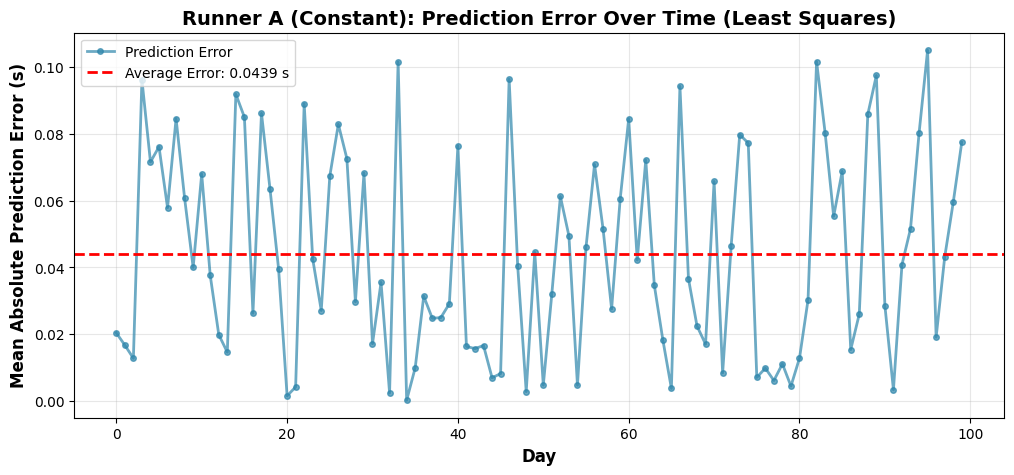

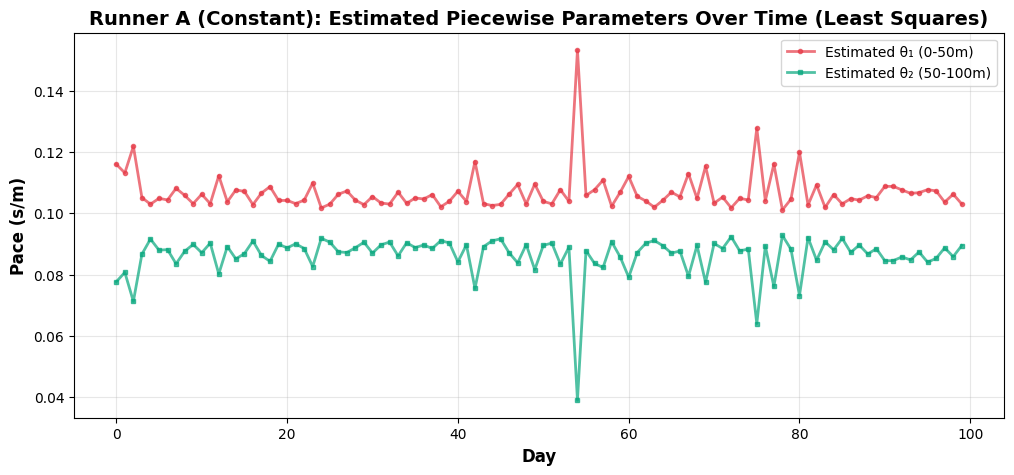

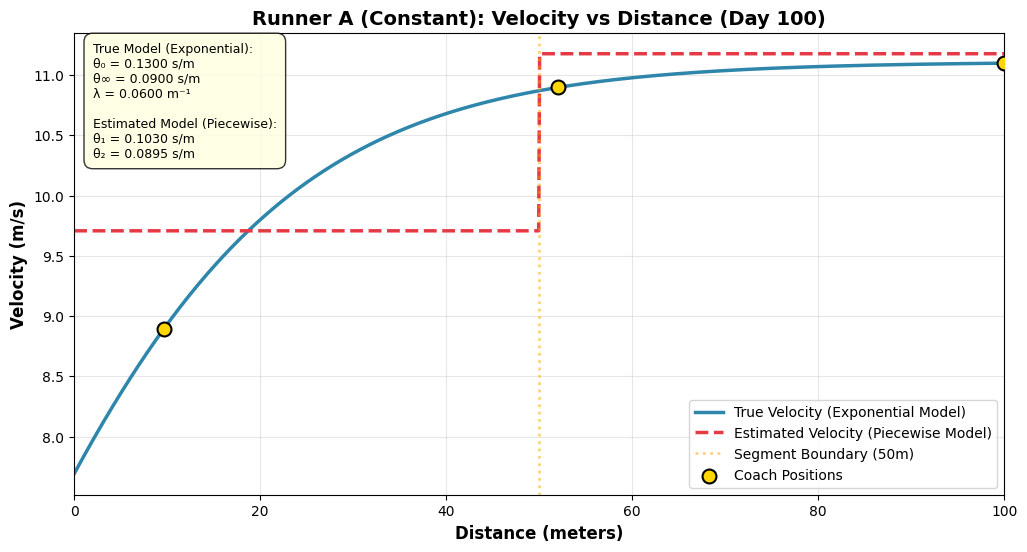

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Least Squares Estimator
# ============================================

class LeastSQ(Estimator):
    """
    Daily Least Squares estimator.
    Estimates parameters independently for each day using standard LS.
    """

    def __init__(self):
        """Initialize the least squares estimator."""
        super().__init__(num_params=2)

    def update(self, A_new, b_new, day=None):
        """
        Estimate parameters for a single day using least squares.

        Parameters:
        -----------
        A_new : array of shape (num_coaches, 2)
            Design matrix
        b_new : array of shape (num_coaches, 1)
            Observation vector
        day : int, optional
            Day number for tracking
        """
        # Check condition number
        if np.linalg.cond(A_new.T @ A_new) < 1 / np.finfo(float).eps:
            # Solve least squares
            x_est = np.linalg.lstsq(A_new, b_new, rcond=None)[0]

            # Compute metrics
            prediction_error, residuals = self._compute_prediction_error(A_new, b_new, x_est)

            # Store results
            self._store_results(x_est, prediction_error, residuals, day)
        else:
            # Ill-conditioned system
            self._store_nan_results(b_new.shape, day)

# Example Usage

if __name__ == "__main__":
    # Assuming runner_A, runner_B, runner_C have been created and runs performed
    num_days_to_simulate = 100

    # Create estimators
    daily_ls = LeastSQ()

    print("Running estimators...")

    # Run estimators day by day for Runner A
    for day in range(num_days_to_simulate):
        A_curr, b_curr, _ = runner_A.get_run_data(day)

        daily_ls.update(A_curr, b_curr, day=day)

    # Get results
    estimates_ls = daily_ls.get_estimate_history()
    errors_ls = daily_ls.get_prediction_error_history()

    # Print summary
    print(f"\nRunner A - Final Estimates (Day {num_days_to_simulate}):")
    print(f"\nDaily LS:")
    print(f"  θ₁: {estimates_ls[-1, 0]:.4f} s/m, θ₂: {estimates_ls[-1, 1]:.4f} s/m")
    print(f"  Avg Error: {np.mean(errors_ls):.4f} s")

    # Plot individual estimator results
    print("\nGenerating plots...")

    # Individual plots
    plot_prediction_errors(runner_A, errors_ls, "Least Squares")
    plot_parameter_estimates(runner_A, estimates_ls, "Least Squares")

    # Combined summary
    # plot_estimation_summary(runner_A, estimates_ls, errors_ls, "Least Squares")

    # Velocity analysis
    plot_velocity_profile(runner_A, estimates_ls, day_idx=-1)
    # plot_velocity_difference(runner_A, estimates_ls, day_idx=-1)
    #plot_velocity_comparison(runner_A, estimates_ls, day_idx=-1,
    #                        prediction_error=errors_ls[-1])

    # Comparisons
    #estimators_dict = {
    #    'LS': (estimates_ls, errors_ls),
    #}

    #compare_estimators_errors(runner_A, estimators_dict)
    #compare_estimators_parameters(runner_A, estimators_dict, param_idx=0)
    #compare_estimators_parameters(runner_A, estimators_dict, param_idx=1)
    #compare_estimators_full(runner_A, estimators_dict)

### Interpretation of Day 1 LS Results
# TODO: REFRACTOR THIS CELL

The Least Squares estimates for Day 1 show a reasonable estimation error, indicating that with more observations than parameters, the system is well-determined. For Day 1, we have `num_runs_per_day = 5` observations and are estimating `num_params = 2` parameters (1 baseline, 1 wind effect). This makes the system overdetermined, allowing for a stable LS solution. While the error is not zero, it's a significant improvement compared to an underdetermined system.

This outcome reinforces the necessity of having sufficient data to reliably estimate parameters, which is why we move to Batch Least Squares and Recursive Least Squares. These methods accumulate observations over time, providing a sufficiently rich dataset for stable and accurate parameter estimation.

## Batch Least Squares for Runner Timing

While the single-day LS provides an immediate estimate, it's often noisy and inaccurate due to limited data. What if we want to use *all* the past data to get a more robust estimate of the runner's baseline ability and wind effect?

This is where **Batch Least Squares** comes in. The idea is to collect all available observations up to a certain point in time and then process them together to obtain a single, comprehensive estimate. This approach assumes that the underlying parameters (runner's baseline, wind effect) are relatively constant over the batch period.

Suppose we collect $K$ observations (timed runs) over several days. Each observation $k$ (which is a single row in our `A` matrix and a single entry in `b`) contributes to a system of equations:

$$ t_k = t_{baseline} + w_{wind} \cdot v_{wind,k} + \epsilon_k $$

Our goal then becomes to solve this optimization problem, minimizing the sum of squared residuals across *all* $K$ observations:

$$ \hat{\mathbf{x}} = \underset{\mathbf{x}}{\operatorname{argmin}} \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 $$

Here, $\mathbf{A}_k$ represents the row of the design matrix corresponding to the $k$-th observation, and $\mathbf{b}_k$ is the $k$-th observed time.

### Batch Least Squares Linear Algebra

The sum of squared norms can be equivalently written using 'stacked' matrices:

$$ \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 = \left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2 $$

Where $\mathbf{A}_{stack}$ and $\mathbf{b}_{stack}$ are formed by vertically concatenating all individual observation matrices and vectors:

$$ \mathbf{A}_{stack} = \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} \quad \text{and} \quad \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} $$

Each $\mathbf{A}_k$ is a $1 \times N$ row vector (where $N$ is the number of parameters, e.g., baseline, wind effect), and $\mathbf{b}_k$ is a $1 \times 1$ scalar (the observed time).
Thus, if we have $K$ observations:

*   $\mathbf{A}_{stack}$ will have dimensions $K \times N$.
*   $\mathbf{b}_{stack}$ will have dimensions $K \times 1$.

The number of parameters $N$ in our runner timing example is $1$ (baseline) + $1$ (wind effect).

This transformation converts the sum of individual least squares problems into a single, larger least squares problem, which can then be solved using the standard Normal Equations.

#### Proof of Equivalence for Sum of Squared Norms and Stacked Matrices

Let's clarify why the expression $\sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2$ is equivalent to $\left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2$.

Recall that the squared Euclidean norm of a vector $\mathbf{v}$ is given by $ \|\mathbf{v}\|_2^2 = \mathbf{v}^T \mathbf{v} = \sum v_i^2 $. In our case, each term $(\mathbf{A}_k \mathbf{x} - \mathbf{b}_k)$ is a scalar, representing the residual $e_k$ for the $k$-th observation. So, the sum of squared norms can be written as:

$$ \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 = \sum_{k=1}^{K} (\mathbf{A}_k \mathbf{x} - \mathbf{b}_k)^2 = e_1^2 + e_2^2 + \dots + e_K^2 $$

Now, let's consider the stacked matrices:

$$ \mathbf{A}_{stack} = \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} \quad \text{and} \quad \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} $$

When we compute the product $\mathbf{A}_{stack} \mathbf{x}$, we get a column vector:

$$ \mathbf{A}_{stack} \mathbf{x} = \begin{bmatrix} \mathbf{A}_1 \mathbf{x} \\ \mathbf{A}_2 \mathbf{x} \\ \vdots \\ \mathbf{A}_K \mathbf{x} \end{bmatrix} $$

The residual vector for the stacked system is then:

$$ \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{A}_1 \mathbf{x} \\ \mathbf{A}_2 \mathbf{x} \\ \vdots \\ \mathbf{A}_K \mathbf{x} \end{bmatrix} - \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} = \begin{bmatrix} \mathbf{A}_1 \mathbf{x} - \mathbf{b}_1 \\ \mathbf{A}_2 \mathbf{x} - \mathbf{b}_2 \\ \vdots \\ \mathbf{A}_K \mathbf{x} - \mathbf{b}_K \end{bmatrix} = \begin{bmatrix} e_1 \\ e_2 \\ \vdots \\ e_K \end{bmatrix} $$

Let's call this stacked residual vector $\mathbf{e}_{stacked}$. Taking its squared Euclidean norm, we get:

$$ \left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2 = \|\mathbf{e}_{stacked}\|_2^2 = e_1^2 + e_2^2 + \dots + e_K^2 $$

By comparing the two final expressions, we can clearly see that:

$$ \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 = \left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2 $$

This equivalence is fundamental for reformulating multiple individual least squares problems into a single, larger batch problem.

Which then results in the familiar LS formulation for the stacked system:

$$ \hat{\mathbf{x}} = (\mathbf{A}_{stack}^T \mathbf{A}_{stack})^{-1} \mathbf{A}_{stack}^T \mathbf{b}_{stack} $$

Alternatively, this can also be expressed as the sum of individual contributions:

$$ \hat{\mathbf{x}} = \left( \sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{A}_k \right)^{-1} \left( \sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{b}_k \right) $$

Where:
*   $\sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{A}_k$ is an $N \times N$ matrix.
*   $\sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{b}_k$ is an $N \times 1$ vector.

This formulation is crucial because it highlights how each new observation contributes to updating the overall sum, which will be fundamental for understanding Recursive Least Squares later.

In [8]:

# ============================================
# Batched Least Squares Estimator
# ============================================

class BatchedLeastSquares(Estimator):
    """
    Batched Least Squares estimator with exponentially weighted forgetting.
    Accumulates data across days.
    """

    def __init__(self, lambda_=1.0):
        """
        Initialize the batched least squares estimator.

        Parameters:
        -----------
        lambda_ : float
            Forgetting factor (1.0 = no forgetting, <1.0 = exponential weighting)
        """
        super().__init__(num_params=2)
        self.lambda_ = lambda_

        # Accumulated matrices
        self._S_accum = np.zeros((self.num_params, self.num_params))
        self._q_accum = np.zeros((self.num_params, 1))

    def update(self, A_new, b_new, day=None):
        """
        Update batch estimate with new data.

        Parameters:
        -----------
        A_new : array of shape (num_coaches, 2)
            Design matrix
        b_new : array of shape (num_coaches, 1)
            Observation vector
        day : int, optional
            Day number for tracking
        """
        # Accumulate with forgetting
        self._S_accum = self.lambda_ * self._S_accum + A_new.T @ A_new
        self._q_accum = self.lambda_ * self._q_accum + A_new.T @ b_new

        # Check condition number
        if np.linalg.cond(self._S_accum) < 1 / np.finfo(float).eps:
            # Solve accumulated system
            x_est = np.linalg.solve(self._S_accum, self._q_accum)

            # Compute metrics on current data
            prediction_error, residuals = self._compute_prediction_error(A_new, b_new, x_est)

            # Store results
            self._store_results(x_est, prediction_error, residuals, day)
        else:
            # Ill-conditioned system
            self._store_nan_results(b_new.shape, day)

## Weighted Least Squares (WLS)

In our runner timing simulation, we've assumed that all measurements are equally reliable. However, in a real-world scenario, this might not be true. For instance, some measurement devices or conditions might lead to lower or higher variance in measurements. When the measurement noise has unequal variances, the standard Ordinary Least Squares (OLS) estimator is no longer the most efficient. This is where **Weighted Least Squares (WLS)** becomes necessary.

### Why WLS?

OLS is optimal (specifically, it's the Best Linear Unbiased Estimator, or BLUE) when the measurement errors are uncorrelated and have equal variance (i.e., homoscedasticity). If the variances are unequal (heteroscedasticity), OLS estimates are still unbiased, but they are no longer efficient, meaning there exists another linear unbiased estimator with smaller variance. WLS accounts for these unequal variances by assigning different 'weights' to each observation based on its reliability.

### WLS Formulation

The WLS objective function minimizes the sum of squared weighted residuals:

$$ \hat{\mathbf{x}}_{WLS} = \underset{\mathbf{x}}{\operatorname{argmin}} \sum_{k=1}^{K} w_k (\mathbf{A}_k \mathbf{x} - \mathbf{b}_k)^2 $$

Or, in matrix form, it minimizes:

$$ \hat{\mathbf{x}}_{WLS} = \underset{\mathbf{x}}{\operatorname{argmin}} (\mathbf{A} \mathbf{x} - \mathbf{b})^T \mathbf{W} (\mathbf{A} \mathbf{x} - \mathbf{b}) $$

Where $\mathbf{W}$ is a diagonal matrix containing the weights $w_k$ on its diagonal. The optimal choice for $\mathbf{W}$ is the inverse of the covariance matrix of the measurement noise, $\mathbf{R}^{-1}$. If the errors are uncorrelated (which is a reasonable assumption for independent measurements), $\mathbf{R}$ is a diagonal matrix, and thus $\mathbf{W}$ is also a diagonal matrix, where each diagonal element $w_k$ is inversely proportional to the variance of the $k$-th measurement noise ($\sigma_k^2$), i.e., $w_k = 1/\sigma_k^2$.

Setting the derivative with respect to $\mathbf{x}$ to zero yields the WLS solution:

$$ \hat{\mathbf{x}}_{WLS} = (\mathbf{A}^T \mathbf{W} \mathbf{A})^{-1} \mathbf{A}^T \mathbf{W} \mathbf{b} $$

In our runner timing scenario, if some measurements are known to be less precise (higher variance) than others, we would assign a smaller weight to those less reliable observations and a larger weight to more reliable ones. This effectively reduces the influence of less reliable data points on the overall parameter estimates.

## Exponential Weighted Least Squares (EWLS)

Building upon the concept of Weighted Least Squares, **Exponential Weighted Least Squares (EWLS)** extends the idea of weighting to account for the temporal relevance of data. In scenarios where parameters might drift or change over time (e.g., the runner's baseline performance improving or changing due to training), it's often desirable to give more importance to recent observations and gradually 'forget' older data.

EWLS achieves this by assigning exponentially decaying weights to older observations within a batch least squares framework. This means that recent data points contribute more significantly to the current parameter estimate, while older data points are progressively down-weighted.

### How `lambda` Acts as a Weight: A More Formal View

Let's consider the objective function for WLS:

$$ \underset{\mathbf{x}}{\operatorname{argmin}} (\mathbf{A} \mathbf{x} - \mathbf{b})^T \mathbf{W} (\mathbf{A} \mathbf{x} - \mathbf{b}) $$

Where $\mathbf{W}$ is the weight matrix. In EWLS, we want to construct $\mathbf{W}$ such that it gives more importance to recent data. Suppose we have $K$ observations collected up to the current time, where observation $i$ occurred at time $i$. For the current time $K$, we define the weight for the $i$-th observation as $w_i = \lambda^{K-i}$. Here, $\lambda$ is the forgetting factor, $0 < \lambda \le 1$.

The stacked design matrix $\mathbf{A}_{stack}$ and observation vector $\mathbf{b}_{stack}$ are:

$$ \mathbf{A}_{stack} = \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} \quad \text{and} \quad \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} $$

Where each $\mathbf{A}_i$ is a $1 \times N$ row vector (representing the $i$-th observation) and $\mathbf{b}_i$ is a scalar.

The weight matrix $\mathbf{W}$ for the stacked system is a diagonal matrix, where each diagonal element corresponds to the weight of the respective observation:

$$ \mathbf{W} = \operatorname{diag}(w_1, w_2, \dots, w_K) = \begin{bmatrix}
\lambda^{K-1} & 0 & \dots & 0 \\
0 & \lambda^{K-2} & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \lambda^{0}
\end{bmatrix} $$

This diagonal matrix $\mathbf{W}$ is directly incorporated into the WLS solution.

### EWLS Formulation for Batch Processing: The Matrix Math

When applying EWLS to a batch of data collected over time, we need to show how the `lambda` terms explicitly weight the contributions of individual observations in the accumulators for $\mathbf{A}^T \mathbf{A}$ and $\mathbf{A}^T \mathbf{b}$.

From the WLS solution, we have:

$$ \hat{\mathbf{x}}_{WLS} = (\mathbf{A}_{stack}^T \mathbf{W} \mathbf{A}_{stack})^{-1} \mathbf{A}_{stack}^T \mathbf{W} \mathbf{b}_{stack} $$

Let's expand the terms $\mathbf{S}_K = \mathbf{A}_{stack}^T \mathbf{W} \mathbf{A}_{stack}$:

$$ \mathbf{S}_K = \begin{bmatrix} \mathbf{A}_1^T & \mathbf{A}_2^T & \dots & \mathbf{A}_K^T \end{bmatrix} \begin{bmatrix}
\lambda^{K-1} & 0 & \dots & 0 \\
0 & \lambda^{K-2} & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \lambda^{0}
\end{bmatrix} \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} $$

First, multiply $\mathbf{W} \mathbf{A}_{stack}$:

$$ \mathbf{W} \mathbf{A}_{stack} = \begin{bmatrix}
\lambda^{K-1} \mathbf{A}_1 \\
\lambda^{K-2} \mathbf{A}_2 \\
\vdots \\
\lambda^{0} \mathbf{A}_K
\end{bmatrix} $$

Then, multiply $\mathbf{A}_{stack}^T$ by this result:

$$ \mathbf{S}_K = \begin{bmatrix} \mathbf{A}_1^T & \mathbf{A}_2^T & \dots & \mathbf{A}_K^T \end{bmatrix} \begin{bmatrix}
\lambda^{K-1} \mathbf{A}_1 \\
\lambda^{K-2} \mathbf{A}_2 \\
\vdots \\
\lambda^{0} \mathbf{A}_K
\end{bmatrix} = \lambda^{K-1} \mathbf{A}_1^T \mathbf{A}_1 + \lambda^{K-2} \mathbf{A}_2^T \mathbf{A}_2 + \dots + \lambda^{0} \mathbf{A}_K^T \mathbf{A}_K $$

Which can be written concisely as a sum:

$$ \mathbf{S}_K = \sum_{i=1}^{K} \lambda^{K-i} \mathbf{A}_i^T \mathbf{A}_i $$

Similarly for $\mathbf{q}_K = \mathbf{A}_{stack}^T \mathbf{W} \mathbf{b}_{stack}$:

$$ \mathbf{q}_K = \begin{bmatrix} \mathbf{A}_1^T & \mathbf{A}_2^T & \dots & \mathbf{A}_K^T \end{bmatrix} \begin{bmatrix}
\lambda^{K-1} & 0 & \dots & 0 \\
0 & \lambda^{K-2} & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \lambda^{0}
\end{bmatrix} \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} $$

First, multiply $\mathbf{W} \mathbf{b}_{stack}$:

$$ \mathbf{W} \mathbf{b}_{stack} = \begin{bmatrix}
\lambda^{K-1} \mathbf{b}_1 \\
\lambda^{K-2} \mathbf{b}_2 \\
\vdots \\
\lambda^{0} \mathbf{b}_K
\end{bmatrix} $$

Then, multiply $\mathbf{A}_{stack}^T$ by this result:

$$ \mathbf{q}_K = \begin{bmatrix} \mathbf{A}_1^T & \mathbf{A}_2^T & \dots & \mathbf{A}_K^T \end{bmatrix} \begin{bmatrix}
\lambda^{K-1} \mathbf{b}_1 \\
\lambda^{K-2} \mathbf{b}_2 \\
\vdots \\
\lambda^{0} \mathbf{b}_K
\end{bmatrix} = \lambda^{K-1} \mathbf{A}_1^T \mathbf{b}_1 + \lambda^{K-2} \mathbf{A}_2^T \mathbf{b}_2 + \dots + \lambda^{0} \mathbf{A}_K^T \mathbf{b}_K $$

Which can be written concisely as a sum:

$$ \mathbf{q}_K = \sum_{i=1}^{K} \lambda^{K-i} \mathbf{A}_i^T \mathbf{b}_i $$

These explicit derivations clearly show that $\lambda^{K-i}$ is the weight applied to the $i$-th observation's contribution. The EWLS estimate at time $K$ is then given by:

$$ \hat{\mathbf{x}}_K = \mathbf{S}_K^{-1} \mathbf{q}_K = \left( \sum_{i=1}^{K} \lambda^{K-i} \mathbf{A}_i^T \mathbf{A}_i \right)^{-1} \left( \sum_{i=1}^{K} \lambda^{K-i} \mathbf{A}_i^T \mathbf{b}_i \right) $$

If we process data sequentially, day by day, we can implement this by updating $\mathbf{S}$ and $\mathbf{q}$ recursively:

At each step $K$ (or for each new batch of data):

$$ \mathbf{S}_{new} = \lambda \mathbf{S}_{old} + \mathbf{A}_{current}^T \mathbf{A}_{current} $$

$$ \mathbf{q}_{new} = \lambda \mathbf{q}_{old} + \mathbf{A}_{current}^T \mathbf{b}_{current} $$

Where $\mathbf{A}_{current}$ and $\mathbf{b}_{current}$ represent the design matrix and observation vector for the *newest* set of data points (e.g., from the current day). The previous accumulated sums ($\mathbf{S}_{old}$ and $\mathbf{q}_{old}$) are 'forgotten' by multiplying by $\lambda$. This recursive update of the sums, combined with the standard LS inversion, provides the EWLS solution. This is implemented in the `BatchedLeastSQ` class by introducing a `lambda_` parameter, allowing it to act as an Exponential Weighted Batch Least Squares estimator.

## Exponential Weighted Least Squares (EWLS)

Building upon the concept of Weighted Least Squares, **Exponential Weighted Least Squares (EWLS)** extends the idea of weighting to account for the temporal relevance of data. In scenarios where parameters might drift or change over time (e.g., the runner's baseline performance improving or changing due to training), it's often desirable to give more importance to recent observations and gradually 'forget' older data.

EWLS achieves this by assigning exponentially decaying weights to older observations. This is conceptually similar to the forgetting factor introduced in Recursive Least Squares (RLS). The weight matrix $\mathbf{W}$ in EWLS is constructed such that measurements taken more recently receive higher weights than older measurements. This makes EWLS a more adaptive method than standard Batch WLS, allowing the estimates to track slowly varying parameters.

If we have a forgetting factor $\lambda$ (where $0 < \lambda \le 1$), the weights might be applied such that the most recent observation has a weight of $1$, the previous observation a weight of $\lambda$, the one before that $\lambda^2$, and so on. This effectively places greater emphasis on current data. This dynamic weighting mechanism is a crucial bridge to understanding how RLS operates, especially when incorporating a forgetting factor, as RLS inherently provides this recency weighting in its recursive updates.

Final Batch LS Estimates for Runner A (Constant):
theta_1: 0.1046, theta_2: 0.0886


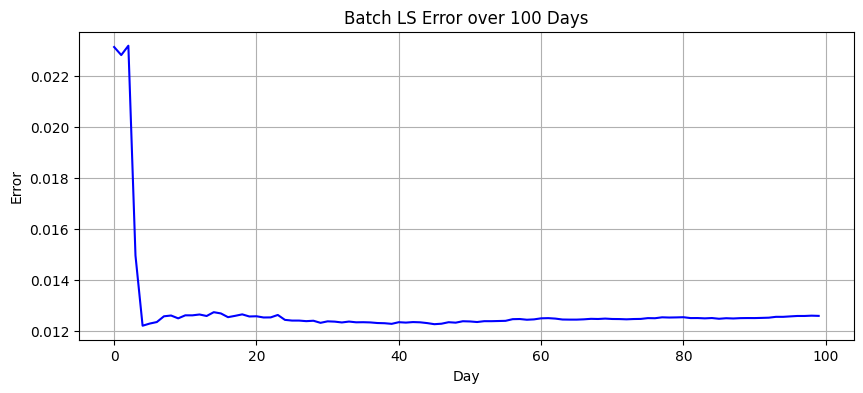

In [16]:
batch_ls_estimator = BatchedLeastSQ(lambda_=1.0)
num_days_to_simulate = runner_A.num_runs

# Run Batch LS day by day using the runner data
for day in range(num_days_to_simulate):
    A_curr, b_curr, _ = runner_A.get_run_data(day)
    batch_ls_estimator.update_batch(A_curr, b_curr, true_params_vec)

batch_estimates = batch_ls_estimator.get_estimate_history()
batch_errors = batch_ls_estimator.get_error_history()

print(f"Final Batch LS Estimates for {runner_A.name}:")
print(f"theta_1: {batch_estimates[-1, 0]:.4f}, theta_2: {batch_estimates[-1, 1]:.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(batch_errors, color='blue')
plt.title(f'Batch LS Error over {num_days_to_simulate} Days')
plt.xlabel('Day')
plt.ylabel('Error')
plt.grid(True)
plt.show()

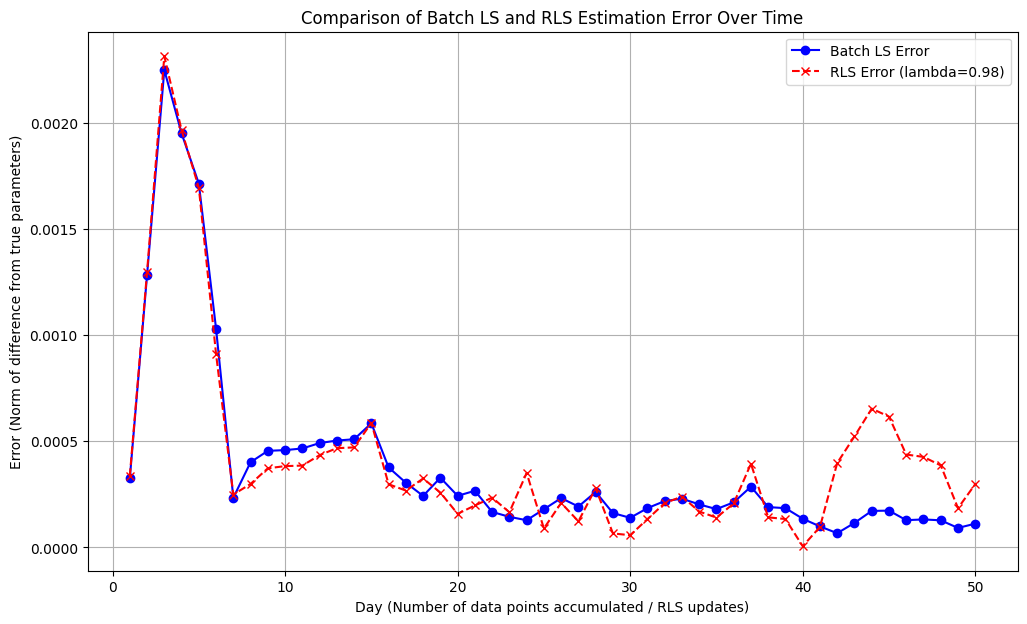

In [ ]:
# Plotting Batch LS and RLS error convergence together
plt.figure(figsize=(12, 7))

plt.plot(range(1, num_days_to_simulate + 1), batch_errors, marker='o', linestyle='-', label='Batch LS Error', color='blue')
plt.plot(range(1, num_days_to_simulate + 1), rls_errors, marker='x', linestyle='--', label=f'RLS Error (lambda={rls_estimator.lambda_})', color='red')

plt.title('Comparison of Batch LS and RLS Estimation Error Over Time')
plt.xlabel('Day (Number of data points accumulated / RLS updates)')
plt.ylabel('Error (Norm of difference from true parameters)')
plt.legend()
plt.grid(True)
plt.show()

## Recursive Least Squares (RLS)

As we saw with Batch Least Squares, combining all past data improves estimation accuracy. However, continuously restacking and re-inverting large matrices can be computationally expensive and memory-intensive, especially as the amount of data grows indefinitely (e.g., in real-time applications).

**Recursive Least Squares (RLS)** provides an elegant solution to this problem. Instead of recalculating the entire estimate from scratch every time a new data point arrives, RLS updates the previous estimate using only the new observation. This 'recursive' nature makes it efficient for online processing and situations where parameters might slowly change over time.

The core idea behind RLS is to maintain an estimate of the inverse of the $\mathbf{A}^T\mathbf{A}$ matrix (often denoted as $\mathbf{P}$) and the $\mathbf{A}^T\mathbf{b}$ vector (often denoted as $\mathbf{q}$), and then update these recursively with each new measurement.

This method not only saves computational resources but also forms the foundation for more advanced filtering techniques like the Kalman Filter, which we can use when the parameters themselves are expected to change dynamically over time (e.g., if the runner's baseline performance is improving daily).

### Recursive Least Squares Math

Let's start by recalling the Batch LS solution written in terms of $\mathbf{S}_K = \sum_{i=1}^{K} \mathbf{A}_i^T \mathbf{A}_i$ and $\mathbf{q}_K = \sum_{i=1}^{K} \mathbf{A}_i^T \mathbf{b}_i$:

$$ \hat{\mathbf{x}}_K = \mathbf{S}_K^{-1} \mathbf{q}_K = \mathbf{P}_K \mathbf{q}_K $$

Where $\mathbf{P}_K = \mathbf{S}_K^{-1}$.

When a new observation arrives at step $K+1$, consisting of $\mathbf{A}_{K+1}$ (a single row vector) and $\mathbf{b}_{K+1}$ (a single scalar), we can update $\mathbf{S}$ and $\mathbf{q}$ recursively:

$$ \mathbf{S}_{K+1} = \mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1} $$

$$ \mathbf{q}_{K+1} = \mathbf{q}_K + \mathbf{A}_{K+1}^T \mathbf{b}_{K+1} $$

The challenge is to efficiently compute the new inverse $\mathbf{P}_{K+1} = \mathbf{S}_{K+1}^{-1}$ without re-inverting the entire matrix. This is where the **Woodbury Matrix Identity** (also known as the Sherman–Morrison–Woodbury formula) becomes incredibly useful:

For matrices $\mathbf{P}$, $\mathbf{H}$, and $\mathbf{R}$ where $\mathbf{P}^{-1}$ and $(\mathbf{R} + \mathbf{H} \mathbf{P} \mathbf{H}^T)^{-1}$ exist:

$$ (\mathbf{P} + \mathbf{H}^T \mathbf{R}^{-1} \mathbf{H})^{-1} = \mathbf{P}^{-1} - \mathbf{P}^{-1} \mathbf{H}^T (\mathbf{R} + \mathbf{H} \mathbf{P}^{-1} \mathbf{H}^T)^{-1} \mathbf{H} \mathbf{P}^{-1} $$

Applying this identity to find $\mathbf{P}_{K+1} = (\mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1})^{-1}$, let:

*   $\mathbf{P} = \mathbf{S}_K^{-1} = \mathbf{P}_K$
*   $\mathbf{H}^T = \mathbf{A}_{K+1}^T$ (so $\mathbf{H} = \mathbf{A}_{K+1}$)
*   $\mathbf{R}^{-1} = \mathbf{I}$ (a $1 \times 1$ identity matrix, as $\mathbf{A}_{K+1}^T \mathbf{A}_{K+1}$ is a rank-1 update; essentially the scalar 1, representing the weighting of the new measurement contribution)

Then the update for $\mathbf{P}$ becomes:

$$ \mathbf{P}_{K+1} = \mathbf{P}_K - \mathbf{P}_K \mathbf{A}_{K+1}^T (\mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} \mathbf{A}_{K+1} \mathbf{P}_K $$

And finally, the update for the estimate $\hat{\mathbf{x}}_{K+1}$ is:

$$ \hat{\mathbf{x}}_{K+1} = \hat{\mathbf{x}}_K + \mathbf{K}_{K+1} (\mathbf{b}_{K+1} - \mathbf{A}_{K+1} \hat{\mathbf{x}}_K) $$

Where $\mathbf{K}_{K+1}$ is the Kalman gain-like term for RLS:

$$ \mathbf{K}_{K+1} = \mathbf{P}_{K+1} \mathbf{A}_{K+1}^T = \mathbf{P}_K \mathbf{A}_{K+1}^T (\mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} $$

This set of equations allows us to update our estimates iteratively, day by day, or run by run, without re-processing all historical data. The term $(\mathbf{b}_{K+1} - \mathbf{A}_{K+1} \hat{\mathbf{x}}_K)$ represents the residual or innovation—the difference between the actual new measurement and what the current model predicted.

### Incorporating Forgetting Factor (Weighted RLS)

Often, in real-world scenarios, the true underlying parameters might not be constant but instead change slowly over time. For example, our runner's baseline performance might improve. To account for this, RLS can be extended with a **forgetting factor** ($\lambda$, where $0 < \lambda \le 1$).

The forgetting factor gives more weight to recent data and gradually 'forgets' older data. This is achieved by modifying the updates for $\mathbf{S}$ and $\mathbf{q}$:

$$ \mathbf{S}_{K+1} = \lambda \mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1} $$

$$ \mathbf{q}_{K+1} = \lambda \mathbf{q}_K + \mathbf{A}_{K+1}^T \mathbf{b}_{K+1} $$

And consequently, the update for $\mathbf{P}$ becomes:

$$ \mathbf{P}_{K+1} = (\lambda \mathbf{P}_K^{-1} + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1})^{-1} $$

Which, using the Woodbury identity, can be rewritten as:

$$ \mathbf{P}_{K+1} = \frac{1}{\lambda} \left( \mathbf{P}_K - \mathbf{P}_K \mathbf{A}_{K+1}^T \left(\lambda \mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T\right)^{-1} \mathbf{A}_{K+1} \mathbf{P}_K \right) $$

And the gain term:

$$ \mathbf{K}_{K+1} = \mathbf{P}_K \mathbf{A}_{K+1}^T (\lambda \mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} $$

If $\lambda=1$, this is standard RLS. If $\lambda < 1$, older data has less influence. A common practice is to initialize $\mathbf{P}_0$ with a large value (e.g., $10^3 \cdot \mathbf{I}$) to reflect high initial uncertainty in the parameters.

### RLS for Runner Timing Simulation

Now, we'll implement the RLS algorithm to track our runner's performance parameters. We will process the daily observations sequentially, updating our estimates each day. This will allow us to observe how the estimates evolve and converge over time, similar to batch LS, but with a more computationally efficient approach for streaming data.

We will use a forgetting factor ($\lambda$) to see how it affects the tracking of potentially changing parameters. For our current simulation, the true parameters are constant, so a $\lambda=1$ (no forgetting) should ideally yield results similar to batch LS as the number of days increases. However, if the runner's baseline was actually improving, a $\lambda < 1$ would be beneficial.

Let's apply the RLS to our simulated daily data.

To conclude, RLS is one of many recursive methods for solving the least squares. It also provides a foundation to the kalman filter, which can be used instead if the target is moving and the parameters themselves are modeled dynamically.

In [9]:
class RecursiveLeastSQ:
    def __init__(self, lambda_=1.0, P0_diag=1e3):
        self.lambda_ = lambda_
        self.num_params = 2
        self.P_k = P0_diag * np.eye(self.num_params)
        self.x_k = np.zeros((self.num_params, 1))
        self.estimates_history = []
        self.error_history = []

    def update(self, A_new, b_new, true_params):
        for i in range(A_new.shape[0]):
            A_i = A_new[i:i+1, :]
            b_i = b_new[i:i+1, :]
            denom = self.lambda_ + A_i @ self.P_k @ A_i.T
            K = (self.P_k @ A_i.T) / denom
            self.x_k = self.x_k + K @ (b_i - A_i @ self.x_k)
            self.P_k = (self.P_k - K @ A_i @ self.P_k) / self.lambda_
        self.estimates_history.append(self.x_k.copy())
        self.error_history.append(np.linalg.norm(self.x_k - true_params))

    def get_estimate_history(self):
        return np.array(self.estimates_history).squeeze()

    def get_error_history(self):
        return np.array(self.error_history)

Final RLS Estimates for Runner A (Constant) (lambda=0.98):
theta_1: 0.1049, theta_2: 0.0881


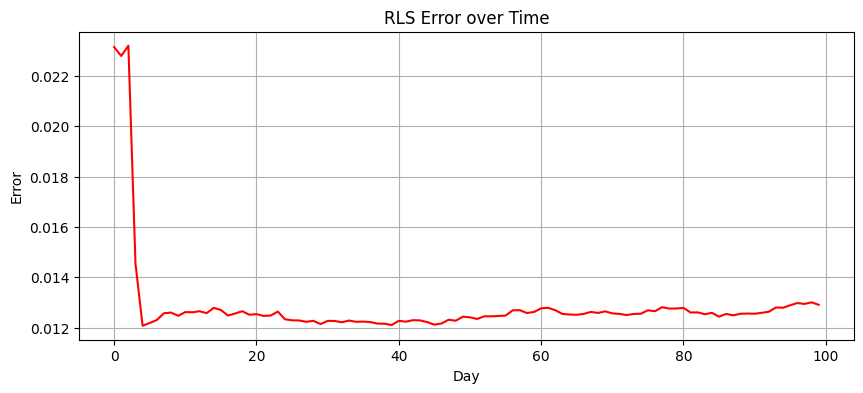

In [17]:
rls_estimator = RecursiveLeastSQ(lambda_=0.98, P0_diag=1e3)

# Run RLS day by day using the runner data
for day in range(num_days_to_simulate):
    A_curr, b_curr, _ = runner_A.get_run_data(day)
    rls_estimator.update(A_curr, b_curr, true_params_vec)

rls_estimates = rls_estimator.get_estimate_history()
rls_errors = rls_estimator.get_error_history()

print(f"Final RLS Estimates for {runner_A.name} (lambda=0.98):")
print(f"theta_1: {rls_estimates[-1, 0]:.4f}, theta_2: {rls_estimates[-1, 1]:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(rls_errors, color='red')
plt.title('RLS Error over Time')
plt.xlabel('Day')
plt.ylabel('Error')
plt.grid(True)
plt.show()

### Comparing Batch LS and RLS Convergence

Let's plot the errors from both Batch LS and RLS on the same graph to visualize their convergence and performance.

We would expect both methods to converge to similar estimates for constant parameters as the amount of data increases, assuming an appropriate forgetting factor (like $\lambda=1$ or close to 1 for RLS). RLS might show a slightly different convergence path due to its sequential updating nature and the impact of the forgetting factor and initial conditions.

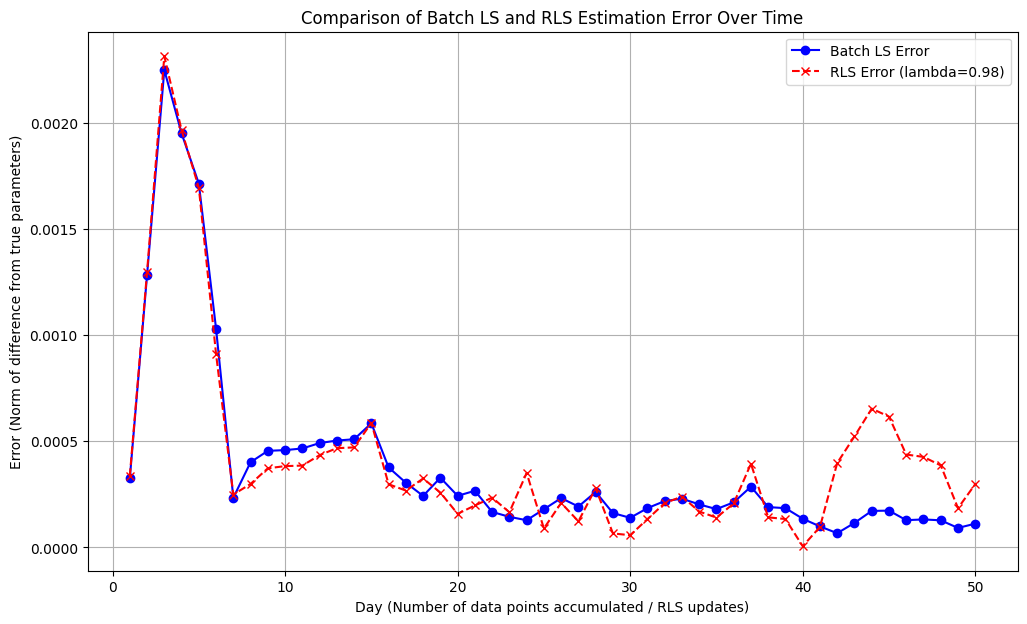

In [12]:
# Plotting Batch LS and RLS error convergence together
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Using the numpy arrays generated from the estimators in cells f7c37491 and 87KR0fli9M4-
plt.plot(range(1, num_days_to_simulate + 1), batch_errors, marker='o', linestyle='-', label='Batch LS Error', color='blue')
plt.plot(range(1, num_days_to_simulate + 1), rls_errors, marker='x', linestyle='--', label=f'RLS Error (lambda={rls_estimator.lambda_})', color='red')

plt.title('Comparison of Batch LS and RLS Estimation Error Over Time')
plt.xlabel('Day (Number of data points accumulated / RLS updates)')
plt.ylabel('Error (Norm of difference from true parameters)')
plt.legend()
plt.grid(True)
plt.show()

### Equivalence between RLS and Batch LS

By setting $P_0$ to a very high value and $\lambda=1$, RLS becomes mathematically equivalent to the Batch Least Squares solution. A small $P_0$ acts like Ridge Regression (L2 regularization), while a very large $P_0$ removes that bias.

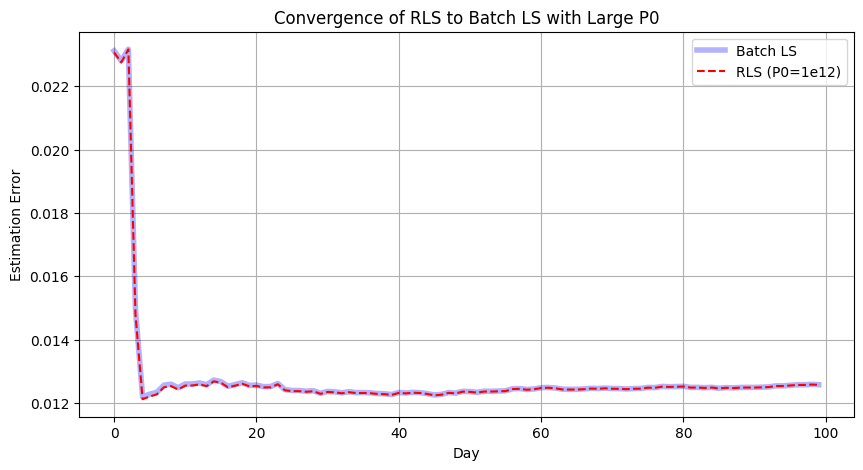

Final Batch Estimate: [0.10458729 0.08864367]
Final RLS Estimate:   [0.10458575 0.08865055]
Difference: 7.047621523792285e-06


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Standard Batch LS (no forgetting)
batch_pure = BatchedLeastSQ(lambda_=1.0)
# 2. RLS with massive P0 (effectively no regularization) and no forgetting
rls_pure = RecursiveLeastSQ(lambda_=1.0, P0_diag=1e12)

for day in range(num_days_to_simulate):
    A, b, _ = runner_A.get_run_data(day)
    batch_pure.update_batch(A, b, true_params_vec)
    rls_pure.update(A, b, true_params_vec)

# Comparison Plot
plt.figure(figsize=(10, 5))
plt.plot(batch_pure.get_error_history(), label='Batch LS', linewidth=4, alpha=0.3, color='blue')
plt.plot(rls_pure.get_error_history(), label='RLS (P0=1e12)', linestyle='--', color='red')
plt.title('Convergence of RLS to Batch LS with Large P0')
plt.xlabel('Day')
plt.ylabel('Estimation Error')
plt.legend()
plt.grid(True)
plt.show()

# Numerical check of the final estimates
print(f"Final Batch Estimate: {batch_pure.get_estimate_history()[-1]}")
print(f"Final RLS Estimate:   {rls_pure.get_estimate_history()[-1]}")
print(f"Difference: {np.linalg.norm(batch_pure.get_estimate_history()[-1] - rls_pure.get_estimate_history()[-1])}")

## Tracking Time-Varying Performance

Now we will apply our estimators to **Runner B (Improving)** and **Runner C (Injured)**. Because their physical parameters change daily, we must compare our estimates against the specific ground truth for each day.

We will use a forgetting factor $\lambda = 0.95$ for the estimators to allow them to 'forget' old, stale data and adapt to the runner's new pace.

In [20]:
def run_tracking_simulation(runner, lambda_val=0.95):
    """Helper to run both estimators and return histories with dynamic true params."""
    batch_sim = BatchedLeastSQ(lambda_=lambda_val)
    rls_sim = RecursiveLeastSQ(lambda_=lambda_val, P0_diag=1e3)

    for day in range(runner.num_runs):
        A, b, _ = runner.get_run_data(day)
        # Get the true parameters for THIS specific day from the runner's history
        tp = runner.true_params_history[day]
        # We are estimating theta_1 and theta_2 (piecewise linear)
        # For simplicity, we approximate the true piecewise parameters from the exponential model history
        true_vec = np.array([[tp['theta_0']], [tp['theta_inf']]])

        batch_sim.update_batch(A, b, true_vec)
        rls_sim.update(A, b, true_vec)

    return batch_sim, rls_sim

# Simulate Runner B (Improving)
batch_B, rls_B = run_tracking_simulation(runner_B, lambda_val=0.95)

# Simulate Runner C (Injured)
batch_C, rls_C = run_tracking_simulation(runner_C, lambda_val=0.95)

print(f"Simulation complete for {runner_B.name} and {runner_C.name}")

Simulation complete for Runner B (Improving) and Runner C (Injured)


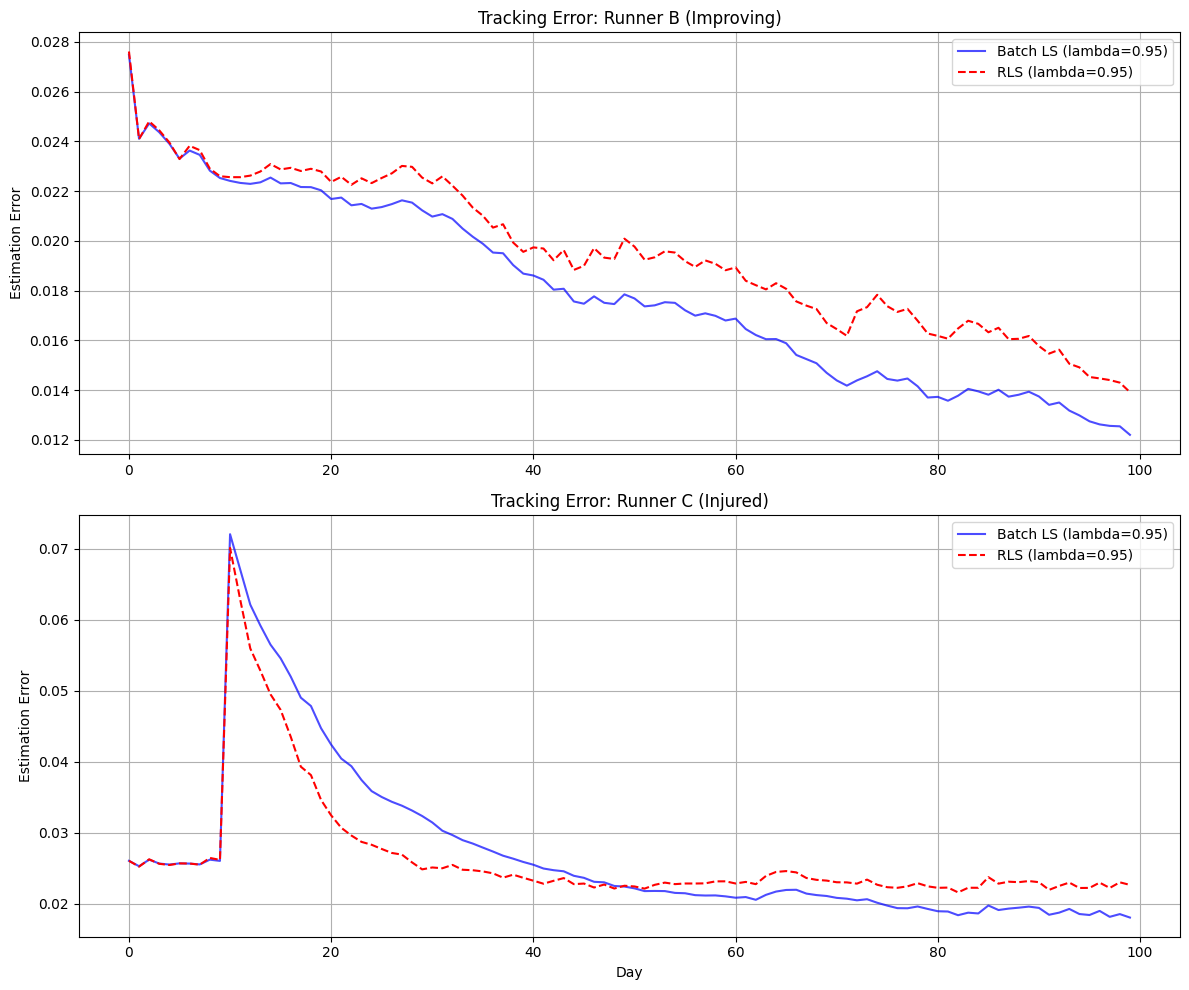

In [21]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Plot Runner B
axs[0].plot(batch_B.get_error_history(), label='Batch LS (lambda=0.95)', color='blue', alpha=0.7)
axs[0].plot(rls_B.get_error_history(), label='RLS (lambda=0.95)', color='red', linestyle='--')
axs[0].set_title(f'Tracking Error: {runner_B.name}')
axs[0].set_ylabel('Estimation Error')
axs[0].legend()
axs[0].grid(True)

# Plot Runner C
axs[1].plot(batch_C.get_error_history(), label='Batch LS (lambda=0.95)', color='blue', alpha=0.7)
axs[1].plot(rls_C.get_error_history(), label='RLS (lambda=0.95)', color='red', linestyle='--')
axs[1].set_title(f'Tracking Error: {runner_C.name}')
axs[1].set_xlabel('Day')
axs[1].set_ylabel('Estimation Error')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

## Tracking Time-Varying Performance

Now we will apply our estimators to **Runner B (Improving)** and **Runner C (Injured)**. Because their physical parameters change daily, we must compare our estimates against the specific ground truth for each day.

We will use a forgetting factor $\lambda = 0.95$ for the estimators to allow them to 'forget' old, stale data and adapt to the runner's new pace.

In [18]:
def run_tracking_simulation(runner, lambda_val=0.95):
    """Helper to run both estimators and return histories with dynamic true params."""
    batch_sim = BatchedLeastSQ(lambda_=lambda_val)
    rls_sim = RecursiveLeastSQ(lambda_=lambda_val, P0_diag=1e3)

    for day in range(runner.num_runs):
        A, b, _ = runner.get_run_data(day)
        # Get the true parameters for THIS specific day
        tp = runner.true_params_history[day]
        true_vec = np.array([[tp['theta_0']], [tp['theta_inf']]])

        batch_sim.update_batch(A, b, true_vec)
        rls_sim.update(A, b, true_vec)

    return batch_sim, rls_sim

# Simulate Runner B (Improving)
batch_B, rls_B = run_tracking_simulation(runner_B, lambda_val=0.95)

# Simulate Runner C (Injured)
batch_C, rls_C = run_tracking_simulation(runner_C, lambda_val=0.95)

print(f"Simulation complete for {runner_B.name} and {runner_C.name}")

Simulation complete for Runner B (Improving) and Runner C (Injured)


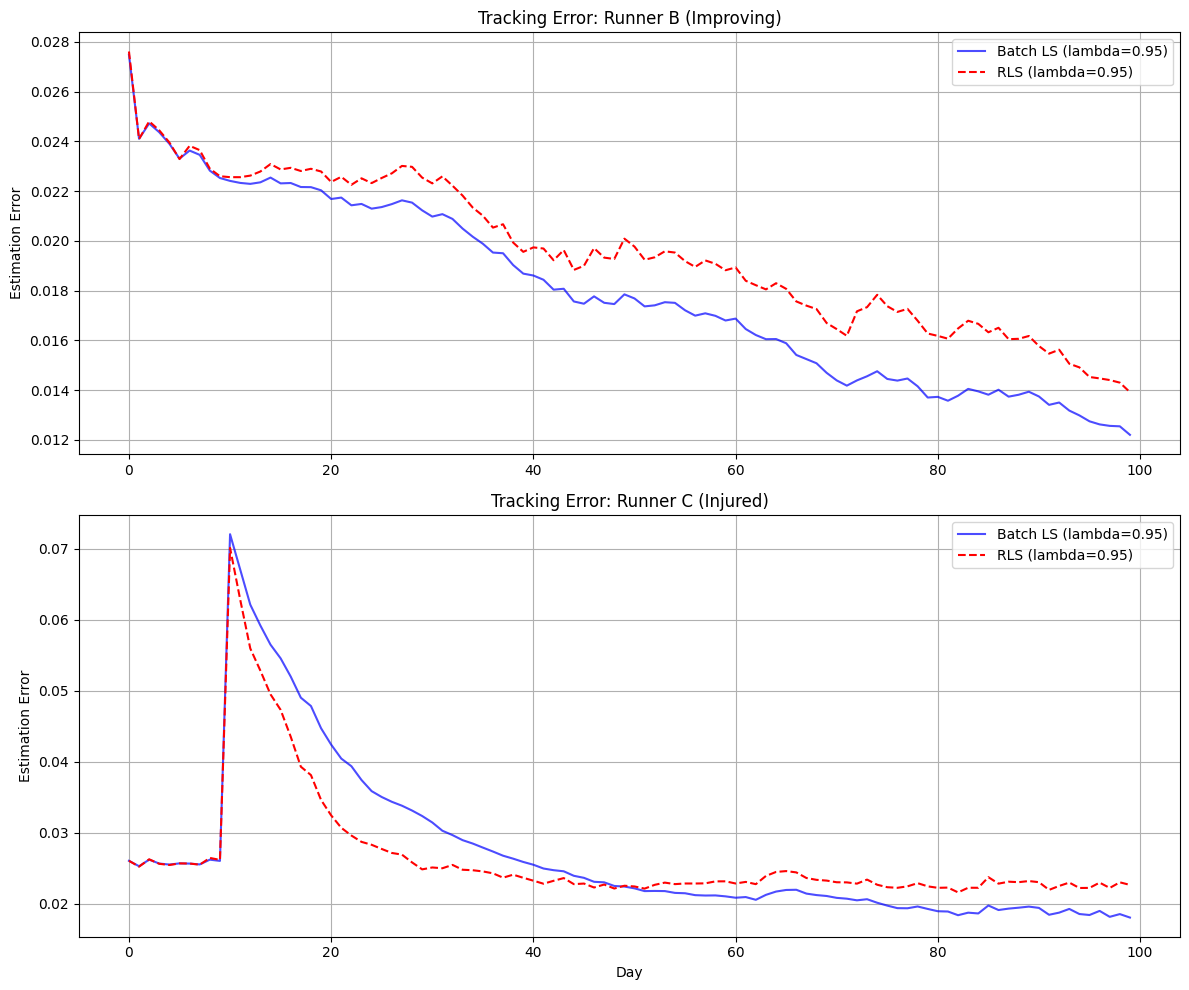

In [19]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Plot Runner B
axs[0].plot(batch_B.get_error_history(), label='Batch LS (lambda=0.95)', color='blue', alpha=0.7)
axs[0].plot(rls_B.get_error_history(), label='RLS (lambda=0.95)', color='red', linestyle='--')
axs[0].set_title(f'Tracking Error: {runner_B.name}')
axs[0].set_ylabel('Estimation Error')
axs[0].legend()
axs[0].grid(True)

# Plot Runner C
axs[1].plot(batch_C.get_error_history(), label='Batch LS (lambda=0.95)', color='blue', alpha=0.7)
axs[1].plot(rls_C.get_error_history(), label='RLS (lambda=0.95)', color='red', linestyle='--')
axs[1].set_title(f'Tracking Error: {runner_C.name}')
axs[1].set_xlabel('Day')
axs[1].set_ylabel('Estimation Error')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()